In [10]:
# =============================================================================
# End-to-end pipeline runner
# =============================================================================
# Executes all four phases in sequence and saves outputs to outputs/.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

from src.config import (
    OHLCV_PATH, N_TRAIN_DAYS, LOT_SIZE, FEE_PER_SHARE, MAX_INV_SHARES,
    GAMMA_GRID_LOG_LO, GAMMA_GRID_LOG_HI, GAMMA_GRID_POINTS,
    Q_MAX_TRIGGER, T_CLOSE, GAMMA_STAR_DEFAULT,
)
from src.data_loader import (
    load_all_sheets, build_calibration_date_split,
    build_price_matrices, preprocess_train_data
)
from src.calibration import calibrate_all_assets, calibrate_eta
from src.risk_matrix import build_sigma, build_Gamma, build_covariance
from src.as_bergault import gamma_sharpe_sweep
from src.almgren_chriss import solve_almgren_chriss, compute_twap_cost
from src.simulation import simulate_integrated, compute_stats

os.makedirs("outputs", exist_ok=True)

In [2]:
raw_sheets  = load_all_sheets(OHLCV_PATH)
asset_names = list(raw_sheets.keys())
asset_data  = {name: preprocess_train_data(raw_sheets[name]) for name in asset_names}


In [11]:
train_date_set, test_date_set = build_calibration_date_split(asset_data, N_TRAIN_DAYS)

prices_all, highs_all, lows_all, timestamps, \
    train_day_indices, test_day_indices = build_price_matrices(
        asset_data, asset_names, train_date_set, test_date_set)

Avec, kvec = calibrate_all_assets(asset_data, asset_names, train_date_set)
phase1_df = pd.DataFrame({'ticker': asset_names, 'A': Avec, 'k': kvec})
phase1_df.to_csv("outputs/phase1_A_k.csv", index=False)    


   Asset          A          k
--------------------------------
    AAPL     1.5621    13.8023
    NVDA     1.7848    12.5443
    AMZN     1.6017    13.7534
    MSFT     1.5742     7.9823
    AVGO     1.6560     5.2460
    META     1.7348     4.4836
    TSLA     1.9870     4.3439
   BRK-B     1.6500    10.3826
     WMT     1.5726    37.2008
     LLY     1.5156     2.6004
     JPM     1.6269    11.3410
     XOM     1.6492    37.6220
       V     1.6135    11.6231
     JNJ     1.4816    23.3795
      MA     1.5409     6.9426
    COST     1.5732     4.8094
    ORCL     1.5703     6.3242
      MU     1.4639     5.9167
    ABBV     1.5639    14.5154


In [12]:

# ── Phase 2: Build Σ and Γ ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PHASE 2: Covariance and Gamma Matrix")
print("=" * 60)
prices_df = pd.DataFrame(prices_all, index=timestamps, columns=asset_names)
Sigma = build_covariance(prices_df, timestamps, train_date_set)
Gamma = build_Gamma(Avec, kvec, Sigma)


PHASE 2: Covariance and Gamma Matrix
Σ shape: (19, 19),  PD: True
Γ shape: (19, 19),  PD: True


In [13]:

# ── Phase 3: Sharpe grid search over γ ───────────────────────────────────────
print("\n" + "=" * 60)
print("PHASE 3: Risk Optimisation (Sharpe Grid Search)")
print("=" * 60)
N=len(asset_names)
gamma_grid = np.logspace(GAMMA_GRID_LOG_LO, GAMMA_GRID_LOG_HI, GAMMA_GRID_POINTS)
results, best = gamma_sharpe_sweep(
    gamma_grid, Avec, kvec, Sigma, Gamma,
    prices_all, train_day_indices, test_day_indices,
    N, LOT_SIZE, FEE_PER_SHARE, MAX_INV_SHARES,
)
gamma_star = best["gamma"]

res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("hs_tr", "hs_te")}
                        for r in results])
res_df.to_csv("outputs/phase3_gamma_star.csv", index=False)
print(f"γ* = {gamma_star:.6e}  saved → outputs/phase3_gamma_star.csv")


PHASE 3: Risk Optimisation (Sharpe Grid Search)

Best gamma: 8.254042e-01  (train Sharpe: 3.894, test Sharpe:  12.929)
γ* = 8.254042e-01  saved → outputs/phase3_gamma_star.csv


In [14]:

# ── Phase 4: Almgren-Chriss liquidation ──────────────────────────────────────
print("\n" + "=" * 60)
print("PHASE 4: Almgren-Chriss Liquidation Regime")
print("=" * 60)

eta_vec, H_matrix = calibrate_eta(raw_sheets, asset_names, train_date_set)

# AC standalone sanity check
test_Q = np.zeros(N)
test_Q[0] = 50; test_Q[1] = -30; test_Q[3] = 40
if N >= 7:  test_Q[6] = -25
if N >= 10: test_Q[9] = 15

N_liq_test          = 60
v_opt, x_path, cost = solve_almgren_chriss(test_Q, N_liq_test, H_matrix, Sigma, gamma_star)
twap_cost           = compute_twap_cost(test_Q, N_liq_test, H_matrix, Sigma, gamma_star)
print(f"\nAC optimal QP cost: {cost:.6f}")
print(f"TWAP baseline cost: {twap_cost:.6f}")
if twap_cost > 0:
    print(f"AC improvement: {(1 - cost / twap_cost) * 100:.2f}%")


PHASE 4: Almgren-Chriss Liquidation Regime
Temporary Impact Calibration (train-only CS spread + ADV):
Asset     Med CS($)   Med DailyVol        eta_i    eta_i/tau
------------------------------------------------------------
AAPL         0.0650     31,588,285     0.000006     0.000006
NVDA         0.0738    127,111,146     0.000003     0.000003
AMZN         0.0642     29,085,262     0.000006     0.000006
MSFT         0.1107     13,042,032     0.000015     0.000015
AVGO         0.1668     14,603,767     0.000022     0.000022
META         0.2044      8,399,144     0.000035     0.000035
TSLA         0.2452     60,208,664     0.000016     0.000016
BRK-B        0.0845      2,532,430     0.000027     0.000027
WMT          0.0226     12,128,483     0.000003     0.000003
LLY          0.2755      1,910,455     0.000100     0.000100
JPM          0.0767      5,107,555     0.000017     0.000017
XOM          0.0241      9,423,153     0.000004     0.000004
V            0.0724      3,975,354     0.00

In [7]:
# ── Full integrated simulation ────────────────────────────────────────────────
print("\nRunning WITH-AC on TRAIN days...")
res_ac_tr = simulate_integrated(
    gamma_star, Avec, kvec, Sigma, Gamma, H_matrix, eta_vec,
    prices_all, train_day_indices, N,
    Q_max=Q_MAX_TRIGGER, T_close=T_CLOSE, use_ac=True)

print("\nRunning WITH-AC on TEST days...")
res_ac_te = simulate_integrated(
    gamma_star, Avec, kvec, Sigma, Gamma, H_matrix, eta_vec,
    prices_all, test_day_indices, N,
    Q_max=Q_MAX_TRIGGER, T_close=T_CLOSE, use_ac=True)

print("\nRunning NO-AC on TRAIN days (pure AS baseline)...")
res_no_tr = simulate_integrated(
    gamma_star, Avec, kvec, Sigma, Gamma, H_matrix, eta_vec,
    prices_all, train_day_indices, N,
    Q_max=Q_MAX_TRIGGER, T_close=T_CLOSE, use_ac=False)

print("\nRunning NO-AC on TEST days (pure AS baseline)...")
res_no_te = simulate_integrated(
    gamma_star, Avec, kvec, Sigma, Gamma, H_matrix, eta_vec,
    prices_all, test_day_indices, N,
    Q_max=Q_MAX_TRIGGER, T_close=T_CLOSE, use_ac=False)

st_ac_tr = compute_stats(res_ac_tr["daily_pnl"])
st_ac_te = compute_stats(res_ac_te["daily_pnl"])
st_no_tr = compute_stats(res_no_tr["daily_pnl"])
st_no_te = compute_stats(res_no_te["daily_pnl"])

print(f"\n{'=' * 85}")
print(f"PERFORMANCE  (γ*={gamma_star:.4e}, Q_max={Q_MAX_TRIGGER}, T_close={T_CLOSE})")
print(f"{'=' * 85}")
print(f"{'Metric':<22} {'AC-train':>14} {'AC-test':>14} {'NoAC-train':>14} {'NoAC-test':>14}")
print("-" * 85)
for label, key in [
    ("Mean PnL ($)",    "mean"),
    ("Std  PnL ($)",    "std"),
    ("Sharpe (daily)",  "sharpe_d"),
    ("Sharpe (annual)", "sharpe_a"),
    ("Win rate (%)",    "winrate"),
    ("Min PnL ($)",     "min_pnl"),
    ("Max PnL ($)",     "max_pnl"),
]:
    print(f"{label:<22} {st_ac_tr[key]:>14.2f} {st_ac_te[key]:>14.2f} "
          f"{st_no_tr[key]:>14.2f} {st_no_te[key]:>14.2f}")

delta_sh_tr = st_ac_tr["sharpe_a"] - st_no_tr["sharpe_a"]
delta_sh_te = st_ac_te["sharpe_a"] - st_no_te["sharpe_a"]
print(f"\nSharpe uplift from AC (annual):  Train {delta_sh_tr:+.2f}   Test {delta_sh_te:+.2f}")



Running WITH-AC on TRAIN days...
  Day 20/93: PnL=$-4,406, AC triggers=2, fills=856, max||Q||=2005
  Day 40/93: PnL=$13,329, AC triggers=2, fills=742, max||Q||=2042
  Day 60/93: PnL=$19,410, AC triggers=3, fills=1111, max||Q||=2015
  Day 80/93: PnL=$7,128, AC triggers=2, fills=469, max||Q||=2035

Running WITH-AC on TEST days...
  Day 20/40: PnL=$12,449, AC triggers=3, fills=1075, max||Q||=2010
  Day 40/40: PnL=$16,916, AC triggers=3, fills=1121, max||Q||=2071

Running NO-AC on TRAIN days (pure AS baseline)...
  Day 20/93: PnL=$9,417, AC triggers=0, fills=1084, max||Q||=2332
  Day 40/93: PnL=$13,451, AC triggers=0, fills=980, max||Q||=2642
  Day 60/93: PnL=$13,062, AC triggers=0, fills=1339, max||Q||=2563
  Day 80/93: PnL=$8,488, AC triggers=0, fills=669, max||Q||=2381

Running NO-AC on TEST days (pure AS baseline)...
  Day 20/40: PnL=$6,166, AC triggers=0, fills=1431, max||Q||=2606
  Day 40/40: PnL=$21,289, AC triggers=0, fills=1356, max||Q||=2520

PERFORMANCE  (γ*=8.2540e-01, Q_max=2

In [8]:
# ── Save outputs ──────────────────────────────────────────────────────────────
def _frame(pnl, split, regime):
    return pd.DataFrame({"day": range(len(pnl)), "pnl": pnl,
                          "split": split, "regime": regime})

pnl_df = pd.concat([
    _frame(res_ac_tr["daily_pnl"], "train", "AC"),
    _frame(res_ac_te["daily_pnl"], "test",  "AC"),
    _frame(res_no_tr["daily_pnl"], "train", "NoAC"),
    _frame(res_no_te["daily_pnl"], "test",  "NoAC"),
], ignore_index=True)
pnl_df.to_csv("outputs/phase4_daily_pnl.csv", index=False)
print("\nDaily PnL saved → outputs/phase4_daily_pnl.csv")


Daily PnL saved → outputs/phase4_daily_pnl.csv


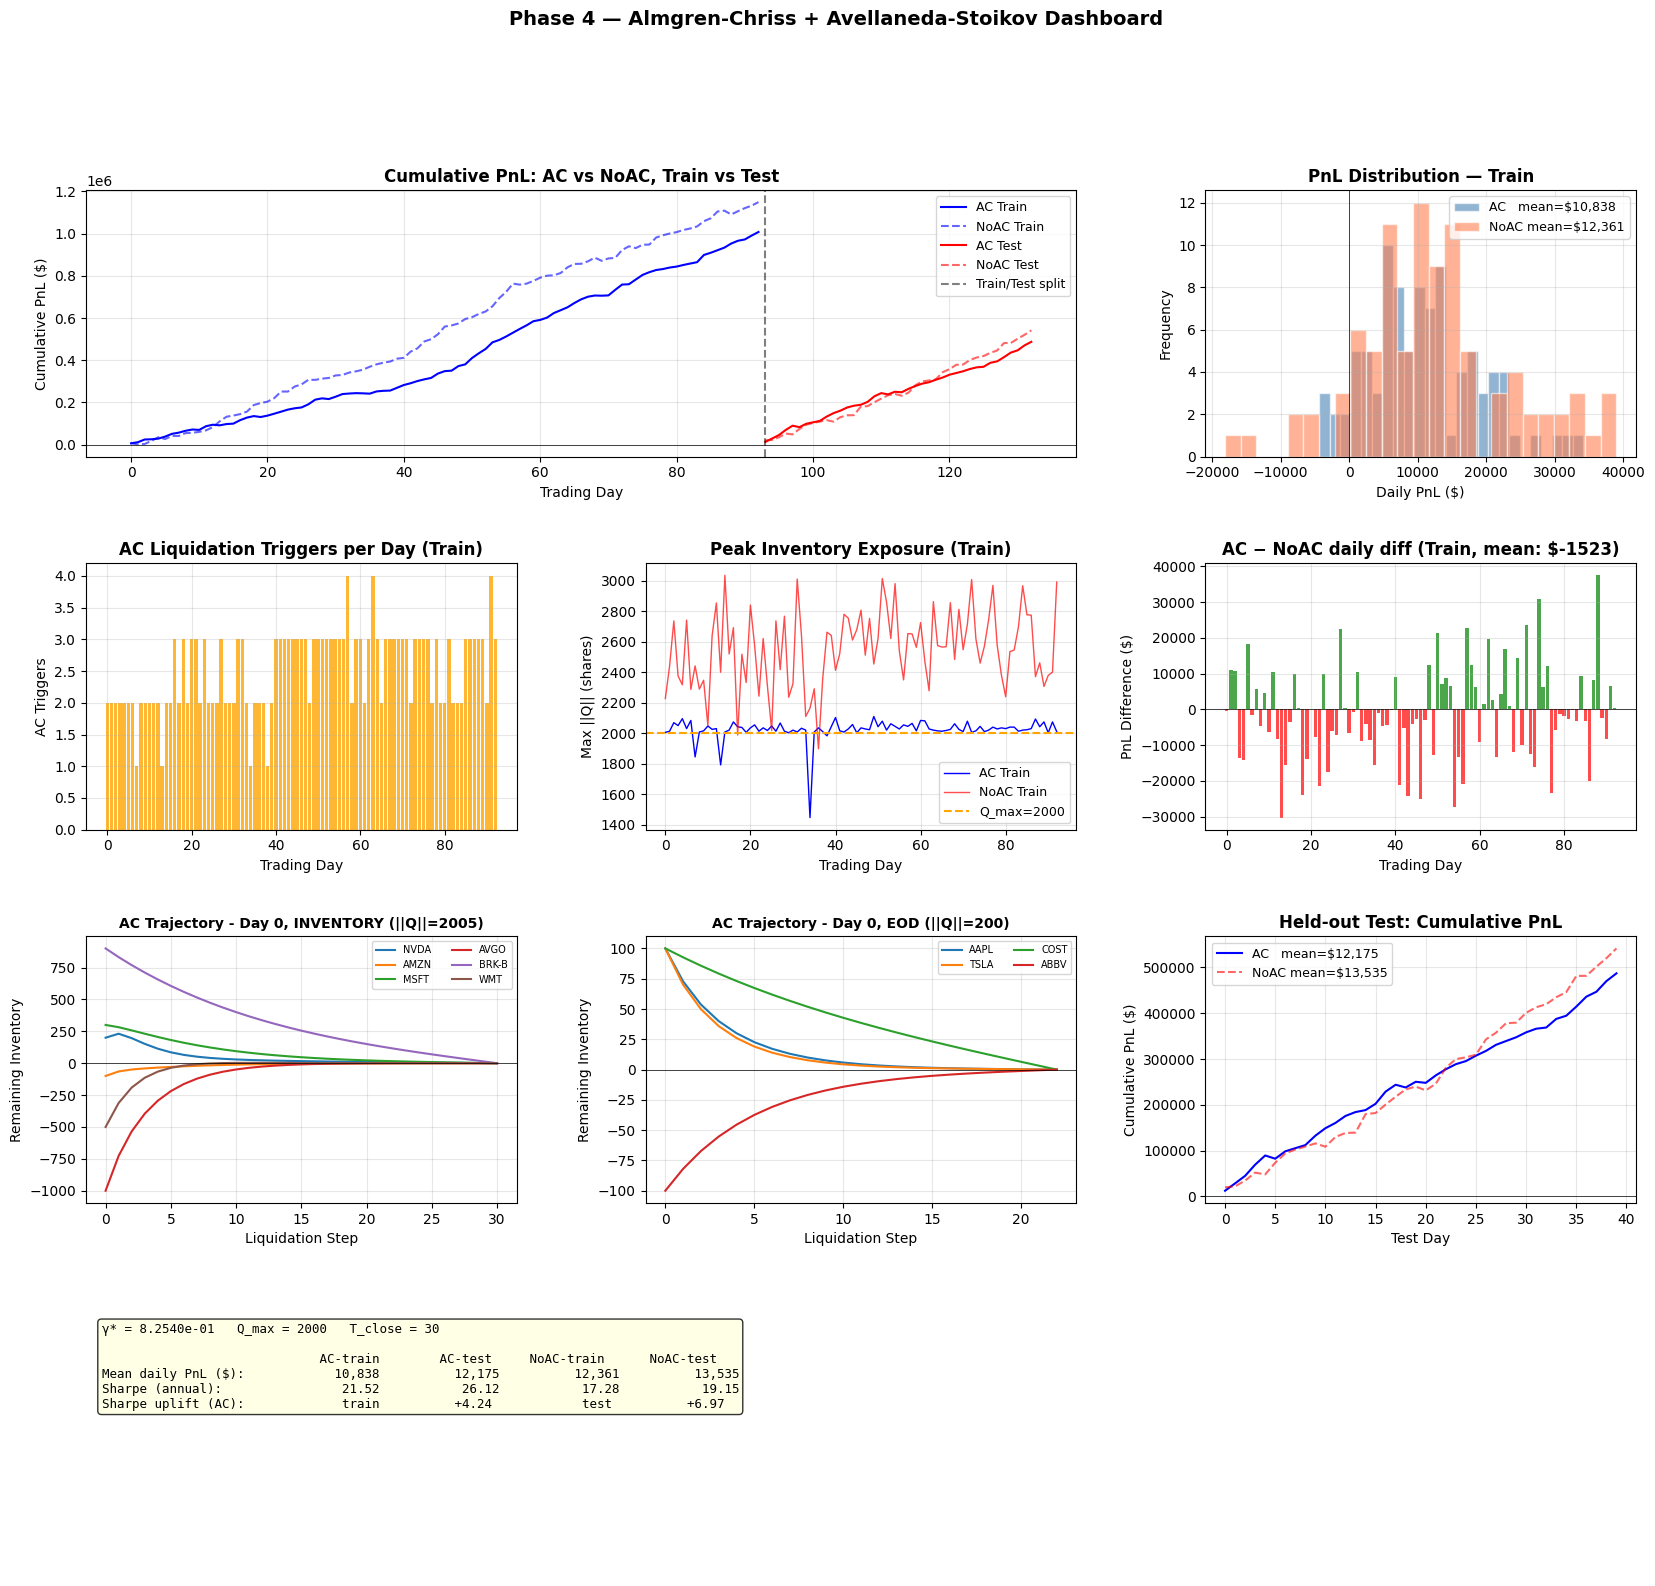

Dashboard saved → outputs/phase4_dashboard.png


In [9]:
# ── Visualisation dashboard ───────────────────────────────────────────────────
pnl_ac_tr = res_ac_tr["daily_pnl"]; pnl_ac_te = res_ac_te["daily_pnl"]
pnl_no_tr = res_no_tr["daily_pnl"]; pnl_no_te = res_no_te["daily_pnl"]

fig = plt.figure(figsize=(20, 18))
gs  = GridSpec(4, 3, figure=fig, hspace=0.4, wspace=0.3)

cum_ac_tr = np.cumsum(pnl_ac_tr); cum_no_tr = np.cumsum(pnl_no_tr)
cum_ac_te = np.cumsum(pnl_ac_te); cum_no_te = np.cumsum(pnl_no_te)
x_tr = range(len(cum_ac_tr))
x_te = range(len(cum_ac_tr), len(cum_ac_tr) + len(cum_ac_te))

ax = fig.add_subplot(gs[0, 0:2])
ax.plot(x_tr, cum_ac_tr, "b-",  linewidth=1.5, label="AC Train")
ax.plot(x_tr, cum_no_tr, "b--", linewidth=1.5, alpha=0.6, label="NoAC Train")
ax.plot(x_te, cum_ac_te, "r-",  linewidth=1.5, label="AC Test")
ax.plot(x_te, cum_no_te, "r--", linewidth=1.5, alpha=0.6, label="NoAC Test")
ax.axvline(len(cum_ac_tr), color="black", linestyle="--", alpha=0.5, label="Train/Test split")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Trading Day"); ax.set_ylabel("Cumulative PnL ($)")
ax.set_title("Cumulative PnL: AC vs NoAC, Train vs Test", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[0, 2])
ax.hist(pnl_ac_tr, bins=25, alpha=0.6, color="steelblue",
        edgecolor="white", label=f"AC   mean=${pnl_ac_tr.mean():,.0f}")
ax.hist(pnl_no_tr, bins=25, alpha=0.6, color="coral",
        edgecolor="white", label=f"NoAC mean=${pnl_no_tr.mean():,.0f}")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Daily PnL ($)"); ax.set_ylabel("Frequency")
ax.set_title("PnL Distribution — Train", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 0])
ax.bar(range(len(res_ac_tr["daily_ac_triggers"])),
       res_ac_tr["daily_ac_triggers"], color="orange", alpha=0.8)
ax.set_xlabel("Trading Day"); ax.set_ylabel("AC Triggers")
ax.set_title("AC Liquidation Triggers per Day (Train)", fontweight="bold")
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 1])
ax.plot(res_ac_tr["daily_inventory_norms"], "b-", linewidth=1, label="AC Train")
ax.plot(res_no_tr["daily_inventory_norms"], "r-", linewidth=1, alpha=0.7, label="NoAC Train")
ax.axhline(Q_MAX_TRIGGER, color="orange", linestyle="--", label=f"Q_max={Q_MAX_TRIGGER}")
ax.set_xlabel("Trading Day"); ax.set_ylabel("Max ||Q|| (shares)")
ax.set_title("Peak Inventory Exposure (Train)", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[1, 2])
pnl_diff_tr = pnl_ac_tr - pnl_no_tr
colors = ["green" if d >= 0 else "red" for d in pnl_diff_tr]
ax.bar(range(len(pnl_diff_tr)), pnl_diff_tr, color=colors, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Trading Day"); ax.set_ylabel("PnL Difference ($)")
ax.set_title(f"AC − NoAC daily diff (Train, mean: ${pnl_diff_tr.mean():+.0f})",
             fontweight="bold")
ax.grid(True, alpha=0.3)

trajs = res_ac_tr["sample_ac_trajectories"]
for plot_i in range(min(2, len(trajs))):
    ax   = fig.add_subplot(gs[2, plot_i])
    traj = trajs[plot_i]
    xp   = traj["x_path"]
    for idx in np.where(np.abs(traj["Q_trigger"]) > 0.5)[0][:6]:
        ax.plot(xp[:, idx], linewidth=1.5, label=asset_names[idx])
    ax.set_xlabel("Liquidation Step"); ax.set_ylabel("Remaining Inventory")
    ax.set_title(f"AC Trajectory - Day {traj['day']}, {traj['reason']} "
                 f"(||Q||={np.linalg.norm(traj['Q_trigger']):.0f})",
                 fontweight="bold", fontsize=10)
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
    ax.axhline(0, color="black", lw=0.5)

ax = fig.add_subplot(gs[2, 2])
ax.plot(cum_ac_te, "b-",  linewidth=1.5, label=f"AC   mean=${pnl_ac_te.mean():,.0f}")
ax.plot(cum_no_te, "r--", linewidth=1.5, alpha=0.6, label=f"NoAC mean=${pnl_no_te.mean():,.0f}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Test Day"); ax.set_ylabel("Cumulative PnL ($)")
ax.set_title("Held-out Test: Cumulative PnL", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[3, :])
ax.axis("off")
summary_text = (
    f"γ* = {gamma_star:.4e}   Q_max = {Q_MAX_TRIGGER}   T_close = {T_CLOSE}\n\n"
    f"{'':22} {'AC-train':>14} {'AC-test':>14} {'NoAC-train':>14} {'NoAC-test':>14}\n"
    f"{'Mean daily PnL ($):':<22} {st_ac_tr['mean']:>14,.0f}  {st_ac_te['mean']:>14,.0f}  "
    f"{st_no_tr['mean']:>14,.0f}  {st_no_te['mean']:>14,.0f}\n"
    f"{'Sharpe (annual):':<22} {st_ac_tr['sharpe_a']:>14.2f}  {st_ac_te['sharpe_a']:>14.2f}  "
    f"{st_no_tr['sharpe_a']:>14.2f}  {st_no_te['sharpe_a']:>14.2f}\n"
    f"{'Sharpe uplift (AC):':<22} {'train':>14} {delta_sh_tr:>+14.2f}  "
    f"{'test':>14} {delta_sh_te:>+14.2f}"
)
ax.text(0.01, 0.95, summary_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Phase 4 — Almgren-Chriss + Avellaneda-Stoikov Dashboard",
             fontsize=14, fontweight="bold")
plt.savefig("outputs/phase4_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved → outputs/phase4_dashboard.png")